Gesamtdatensatz enthält 2000000 Einträge.


Lade Bilder: 100%|██████████| 2400/2400 [00:01<00:00, 1537.01it/s]


Validation Set - F1 Score: 0.1568765388673936, Precision: 0.45979381443298967, Recall: 0.09457167090754877, Accuracy: 0.500625
Test Set - F1 Score: 0.15546218487394958, Precision: 0.46835443037974683, Recall: 0.09319899244332494, Accuracy: 0.4975


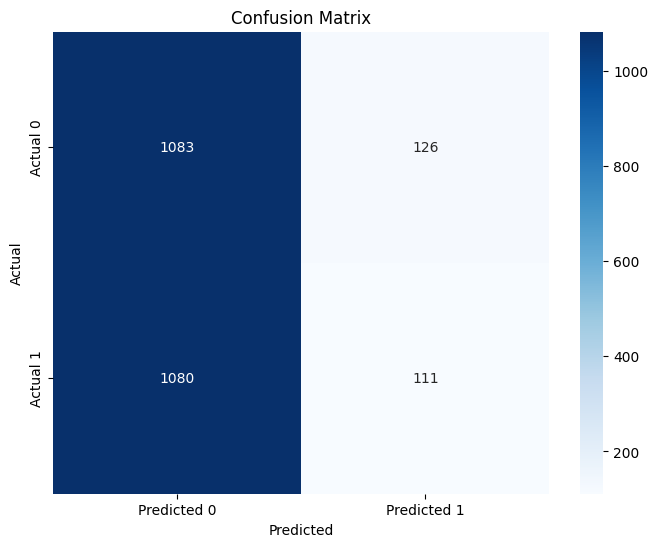

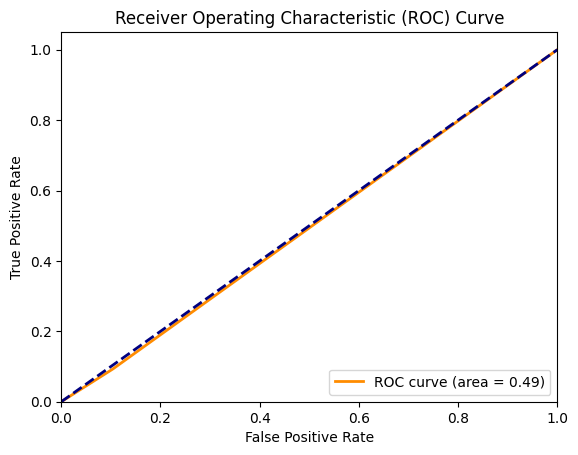

In [2]:
import os
import pymongo
import pandas as pd
import numpy as np
import base64
from PIL import Image
import io
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc

# Load and Merge Data (Assuming MongoDB setup is correct)
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

# Preprocess Data

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image)  # No normalization
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

# Function to extract images and labels from DataFrame
def extract_images_from_df(df, example_user_id):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Example user ID
example_user_id = 'benutzername_1'

# Create DataFrames for each user
user_ids = merged_df['username'].unique()
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Sample data for the example user
user_df = user_dfs[example_user_id].sample(n=12000, random_state=42)

# Add negative examples and limit
negative_df = pd.concat([user_dfs[user_id] for user_id in user_ids if user_id != example_user_id])
negative_df = negative_df.sample(n=12000, random_state=42)

# Split into Train/Val/Test sets (70% Train, 20% Val, 10% Test)
train_df, test_df = train_test_split(pd.concat([user_df, negative_df]), test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2

# Process image data
try:
    X_train, y_train = extract_images_from_df(train_df, example_user_id)
    X_val, y_val = extract_images_from_df(val_df, example_user_id)
    X_test, y_test = extract_images_from_df(test_df, example_user_id)
except Exception as e:
    print(f"Fehler bei der Bilddatenverarbeitung: {e}")

# Free up memory
gc.collect()

# Train Isolation Forest
# Flatten the image data for Isolation Forest
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train the model
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(X_train_flat)

# Predict on validation and test sets
y_val_pred = model.predict(X_val_flat)
y_test_pred = model.predict(X_test_flat)

# Convert predictions from {-1, 1} to {0, 1}
y_val_pred = np.where(y_val_pred == 1, 0, 1)
y_test_pred = np.where(y_test_pred == 1, 0, 1)

# Evaluate the model
# Validation set evaluation
f1_val = f1_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)

print(f"Validation Set - F1 Score: {f1_val}, Precision: {precision_val}, Recall: {recall_val}, Accuracy: {accuracy_val}")

# Test set evaluation
f1_test = f1_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"Test Set - F1 Score: {f1_test}, Precision: {precision_test}, Recall: {recall_test}, Accuracy: {accuracy_test}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [3]:
# Datenaufteilung
def split_data(df):
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.6667, random_state=42)  # 0.6667 * 0.3 = 0.2
    return train_df, val_df, test_df

# Beispiel für die Aufteilung der Daten eines Benutzers
user_id = fingerprints_df.iloc[2]['_id']  # Benutzer 3
username = fingerprints_df.iloc[2]['username']
user_samples = canvassamples_df[canvassamples_df['fingerprintId'] == user_id]
train_df, val_df, test_df = split_data(user_samples)

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib

# Isolation Forest Modell trainieren
def train_isolation_forest(df):
    if df['numeric_sampleData'].empty:
        raise ValueError("Die numeric_sampleData-Spalte ist leer.")
    
    stats_df = pd.DataFrame(df['statistics'].tolist())
    hist_df = pd.DataFrame(df['histogram'].tolist())
    
    X = pd.concat([stats_df, hist_df], axis=1)
    X.columns = X.columns.astype(str)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = IsolationForest(contamination=0.1)
    model.fit(X_scaled)
    
    return model, scaler

# Modell trainieren und speichern
def train_and_save_model(train_df, username):
    train_df_prepared = prepare_data(train_df)
    isolation_forest_model, scaler = train_isolation_forest(train_df_prepared)
    
    os.makedirs('Modelle/IsolationForest2', exist_ok=True)
    joblib.dump(isolation_forest_model, f'Modelle/IsolationForest2/{username}_model.pkl')
    joblib.dump(scaler, f'Modelle/IsolationForest2/{username}_scaler.pkl')
    print(f"Modell und Scaler für {username} gespeichert.")
    
    return isolation_forest_model, scaler

# Modell für den Benutzer trainieren und speichern
isolation_forest_model, scaler = train_and_save_model(train_df, username)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Vorhersagen treffen
def make_predictions(df, model, scaler):
    df_prepared = prepare_data(df)
    stats_df = pd.DataFrame(df_prepared['statistics'].tolist())
    hist_df = pd.DataFrame(df_prepared['histogram'].tolist())
    
    X = pd.concat([stats_df, hist_df], axis=1)
    X.columns = X.columns.astype(str)
    
    X_scaled = scaler.transform(X)
    preds = model.predict(X_scaled)
    
    preds = np.where(preds == -1, 0, 1)
    df.loc[:, 'anomaly'] = preds
    return df

# Grafische Darstellung der Ergebnisse
def plot_results(df, title):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='anomaly', data=df)
    plt.title(title)
    plt.xlabel('Anomaly')
    plt.ylabel('Count')
    plt.show()

# Modell gegen 10 Samples von Benutzer 3 testen
user_samples_test = test_df.sample(10, random_state=42)
predictions_user = make_predictions(user_samples_test, isolation_forest_model, scaler)
plot_results(predictions_user, f'Anomalien in 10 Samples von {username}')

# Modell gegen 5 zufällige Samples von anderen Benutzern testen
other_users_samples = canvassamples_df[canvassamples_df['fingerprintId'] != user_id].sample(5, random_state=42)
predictions_other = make_predictions(other_users_samples, isolation_forest_model, scaler)
plot_results(predictions_other, f'Anomalien in 5 zufälligen Samples von anderen Benutzern')

In [ ]:
# Ergebnisse erklären
def explain_results(predictions, title):
    total_samples = predictions.shape[0]
    anomalies = predictions['anomaly'].sum()
    normal = total_samples - anomalies
    
    print(f"{title}")
    print(f"Gesamtanzahl der Samples: {total_samples}")
    print(f"Anzahl der Anomalien: {anomalies}")
    print(f"Anzahl der normalen Samples: {normal}")
    print("\n")

# Ergebnisse für Benutzer 3 erklären
explain_results(predictions_user, f'Ergebnisse für 10 Samples von {username}')

# Ergebnisse für andere Benutzer erklären
explain_results(predictions_other, 'Ergebnisse für 5 zufällige Samples von anderen Benutzern')

In [ ]:
# Modell gegen 5 verschiedene Benutzer mit je 10 Samples testen
def test_model_against_multiple_users(model, scaler, num_users=5, samples_per_user=10):
    other_users = fingerprints_df[fingerprints_df['_id'] != user_id].sample(num_users, random_state=42)
    for _, user in other_users.iterrows():
        other_user_id = user['_id']
        other_username = user['username']
        other_user_samples = canvassamples_df[canvassamples_df['fingerprintId'] == other_user_id].sample(samples_per_user, random_state=42)
        predictions_other_user = make_predictions(other_user_samples, model, scaler)
        plot_results(predictions_other_user, f'Anomalien in 10 Samples von {other_username}')
        explain_results(predictions_other_user, f'Ergebnisse für 10 Samples von {other_username}')

# Testen des Modells gegen 5 verschiedene Benutzer mit je 10 Samples
test_model_against_multiple_users(isolation_forest_model, scaler, num_users=5, samples_per_user=10)